In [1]:
import glob
import time
from typing import Callable, Literal

import h5py
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from statsmodels.robust.norms import RobustNorm, TukeyBiweight 

In [2]:
from dev import nonlinear_fit, fit_baseline_fluctuations, AsymmetricTukeyBiweight, AsymmetricTukeyBiweight_jax

In [3]:
%matplotlib inline

## Function definitions

In [4]:
def double_exp_bright_jax(params, t):
    """
    Bright baseline with biphasic decay and saturating brightening.

    Parameters
    ----------
    params : np.ndarray
        Parameter vector: [b_inf, b_slow, b_fast, b_bright,
                           t_slow, t_fast, t_bright]
    t : np.ndarray
        Timestamps

    Returns
    -------
    y : np.ndarray
        Model prediction
    """
    b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright = params
    # exponentials
    E_slow = jnp.exp(-t / t_slow)
    E_fast = jnp.exp(-t / t_fast)
    E_bright = jnp.exp(-t / t_bright)
    # helper terms
    A = 1 + b_slow * E_slow + b_fast * E_fast
    B = 1 - b_bright * E_bright

    y = b_inf * A * B
    return y

#### load data 

In [5]:
def get_valid_corrected_f(path):
    dr = path.split("/")[-1]
    data = []
    with h5py.File(f"{path}/{dr}_data.h5") as f:
        for k in f['planes'].keys():
            data.append(f[f'planes/{k}/corrected_f'][f[f'planes/{k}/valid_roi_inds'][:]])
    return data

## Data 

In [6]:
dirs = glob.glob("/data/test-dataset-for-dff_multiplane-ophys_02/*/*")
dirs

['/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/804670',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/775682',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/782149',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753562',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/729088',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/758265',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753561',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/724567',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/755212',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/759075',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/726433',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/747443',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/757436',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/69

In [7]:
traces = get_valid_corrected_f(dirs[0])

In [8]:
trace = traces[0][0]

In [9]:
frame_rate = 10.63  # looked up manually from session.json of multiplane-ophys_804670_2025-09-24_09-30-56_processed_2025-10-10_22-28-44
timestamps = np.arange(len(trace)) / frame_rate

## fit baseline fluctuations

In [10]:
double_exp_bright_init = [trace[-1000:].mean(), 0.35, 0.2, 0.99, 3600, 240, 1e5]
double_exp_bright_bounds = [(0, np.inf)] * 4 + [(300, np.inf), (1, 1200), (1, np.inf)]

In [11]:
def fit_baseline(
    trace: np.ndarray,
    t: np.ndarray,
    model: Callable,
    init_params: np.ndarray,
    bounds: tuple[tuple[float, float], ...] | None = None,
    M: RobustNorm | None = None,
    optimizer: str = "L-BFGS-B",
    optimizer_options: dict | None = dict(maxiter=20000, ftol=1e-12, gtol=1e-10),
    backend: Literal["numpy", "jax"] = "numpy",
    mode: Literal["ratio", "subtract"] = "ratio",
    frac: float = 0.1,
    method: Literal["lowess", "percentile"] = "lowess",
    maxiter: int = 5,
    tol: float = 1e-3,
    percentile: float | None = None,
):
    F0trend, res = nonlinear_fit(trace, t, model, init_params, bounds, M, optimizer, maxiter, tol, 
                                 optimizer_options=optimizer_options, backend=backend)
    F0, F0fluct = fit_baseline_fluctuations(trace, t, F0trend, mode, frac, res.weights, method, M, maxiter, tol, percentile)
    return F0, F0trend

In [12]:
def plot_dff(F, F0, F0trend, t=None, zoom_duration=60.0):
    if t is None:
        t = np.arange(len(F))
    show_insets = zoom_duration is not None and zoom_duration > 0
    if show_insets:
        fig, ax=plt.subplots(5,1,figsize=(15,6), sharex=True)
    else:
        fig, ax=plt.subplots(4,1,figsize=(15,5), sharex=True)
    ax[0].plot(t, trace, label="$F$")
    ax[0].plot(t, F0trend, label="$F0_{trend}$")
    ax[0].plot(t, F0, label="$F0$")
    ax[0].set_ylabel("$F$ [a.u.]")
    ax[1].plot(t, trace-F0trend, c="C1", label="$F-F0_{trend}$")
    ax[1].axhline(0, ls="--", c="k")
    ax[1].plot(t, F0-F0trend, c="C2", label="$F0_{fluctuations}$")
    ax[1].set_ylabel("$\\Delta F$ [a.u.]")
    ax[2].plot(t, 100 * (trace/F0trend-1), c="C1", label="$\\frac{\\Delta F_{trend}}{F0_{trend}}$")
    ax[2].axhline(0, ls="--", c="k")
    ax[2].set_ylabel(r"$\Delta$F/F [%]")
    ax[3+show_insets].plot(t, 100 * (trace/F0trend-1), c="C2", label="$\\frac{\\Delta F}{F}$")
    ax[3+show_insets].axhline(0, ls="--", c="k")
    ax[3+show_insets].set_ylabel(r"$\Delta$F/F [%]", y=1 if show_insets else 0.5)
    for a in ax[:3]:
        a.legend(loc=1)
    ax[-1].legend(loc=1)
    
    # Add insets if requested
    if show_insets:
        t_total = t[-1] - t[0]
        dff_trace = F/F0 - 1
        zoom_windows = [
            (t[0], t[0] + zoom_duration),
            (
                t[0] + (t_total - zoom_duration) / 2,
                t[0] + (t_total + zoom_duration) / 2,
            ),
            (max(t[-1] - zoom_duration, t[0]), t[-1]),
        ]
    
        ax[3].axis("off")
    
        for j, (start_time, end_time) in enumerate(zoom_windows):
            inset_ax = inset_axes(
                ax[3],
                width="100%",
                height="100%",
                loc="center",
                bbox_to_anchor=([0.01, 0.34, 0.67][j], 0.0, 0.32, 0.8),
                bbox_transform=ax[3].transAxes,
            )
    
            mask = (t >= start_time) & (t <= end_time)
            if np.any(mask):
                t_zoom, dff_zoom = t[mask], dff_trace[mask] * 100
    
                inset_ax.plot(t_zoom, dff_zoom, c="C2", lw=0.5)
                inset_ax.axhline(0, c="k", ls="--")
                inset_ax.grid(True, alpha=0.8)
                inset_ax.set_xlim(start_time, end_time)
    
                if len(dff_zoom) > 0:
                    mi, ma = np.nanmin(dff_zoom), np.nanmax(dff_zoom)
                    y_margin = 0.1 * (ma - mi)
                    if ~np.isnan(y_margin):
                        inset_ax.set_ylim(mi - y_margin, ma + y_margin)
    
                inset_ax.set_title(
                    f"{['First', 'Middle', 'Last'][j]} {zoom_duration:.0f}s",
                    fontsize=10,
                    y=0.94,
                )
                inset_ax.set_xticks([])
                inset_ax.set_yticks([])
    
                mark_inset(
                    ax[4],
                    inset_ax,
                    loc1=1,
                    loc2=3,
                    fc="none",
                    ec="#333333",
                    alpha=0.8,
                    linestyle="--",
                    linewidth=1,
                )
        
    a.set_xlim(-.01*t[-1], 1.01*t[-1])
    ax[-1].set_xlabel("Time [frames]" if t[1]==1 else "Time [s]")
    plt.subplots_adjust(hspace=0.1, top=0.935, bottom=0.13, left=0.06, right=0.995)

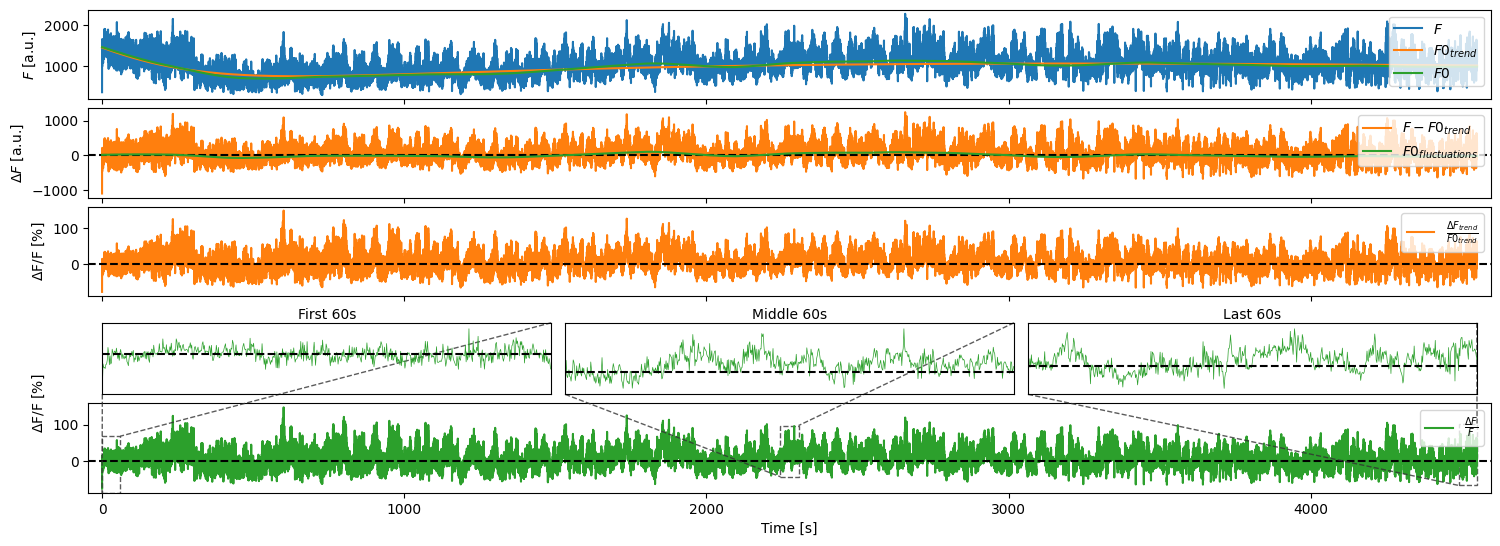

In [13]:
F0, F0trend = fit_baseline(trace, timestamps, double_exp_bright_jax, double_exp_bright_init, double_exp_bright_bounds,
    M=AsymmetricTukeyBiweight(2, 3), backend="numpy")
plot_dff(trace, F0, F0trend, t=timestamps, zoom_duration=60.0)